# Exploratory Data Analysis (EDA) - Final Dataset
**Dataset:** `dataset/final_dataset_ready_for_modeling.csv`
**Objective:** Comprehensive analysis of the prepared dataset before modeling. Focus on target distribution, temporal trends, correlations, and feature relationships.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Config
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
DATA_PATH = 'dataset/final_dataset_ready_for_modeling.csv'

# Load Data
df = pd.read_csv(DATA_PATH)
df['tanggal'] = pd.to_datetime(df['tanggal'])

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (15412, 48)


,tanggal,stasiun,pm10,pm25,so2,co,o3,no2,max,critical_parameter,...,nama_libur,is_weekend,day_name,is_working_day,tahun,Total_Penduduk,ndvi,month,year,day_of_week
0,2010-01-01,DKI1,60.0,65.496864,4.0,73.0,27.0,14.0,73.0,CO,...,New Year's Day,0.0,Friday,0,2010.0,902973.0,0.202300,1.0,2010.0,4.0
1,2010-01-02,DKI1,32.0,51.534592,2.0,16.0,33.0,9.0,33.0,O3,...,NaN,1.0,Saturday,0,2010.0,902973.0,0.203619,1.0,2010.0,5.0
2,2010-01-03,DKI1,27.0,43.427841,2.0,19.0,20.0,9.0,27.0,PM10,...,NaN,1.0,Sunday,0,2010.0,902973.0,0.204937,1.0,2010.0,6.0
3,2010-01-04,DKI1,22.0,35.773327,2.0,16.0,15.0,6.0,22.0,PM10,...,NaN,0.0,Monday,1,2010.0,902973.0,0.206256,1.0,2010.0,0.0
4,2010-01-05,DKI1,25.0,37.706676,2.0,17.0,15.0,8.0,25.0,PM10,...,NaN,0.0,Tuesday,1,2010.0,902973.0,0.207575,1.0,2010.0,1.0


In [27]:
# Data Overview
print("--- Info ---")
df.info()

print("\n--- Numerical Summary ---")
display(df.describe())

print("\n--- Categorical Summary ---")
display(df.describe(include=['O']))

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 15412 entries, 0 to 15411
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   tanggal                      15085 non-null  datetime64[us]
 1   stasiun                      15410 non-null  str           
 2   pm10                         15412 non-null  float64       
 3   pm25                         15412 non-null  float64       
 4   so2                          15412 non-null  float64       
 5   co                           15412 non-null  float64       
 6   o3                           15412 non-null  float64       
 7   no2                          15412 non-null  float64       
 8   max                          15412 non-null  float64       
 9   critical_parameter           15366 non-null  str           
 10  target_kategori              15412 non-null  str           
 11  temperature_2m_max           15083 non-

,tanggal,pm10,pm25,so2,co,o3,no2,max,temperature_2m_max,temperature_2m_min,...,rainy_day,is_holiday_nasional,is_weekend,is_working_day,tahun,Total_Penduduk,ndvi,month,year,day_of_week
count,15085,15412.000000,15412.000000,15412.000000,15412.000000,15412.000000,15412.000000,15412.000000,15083.000000,15083.000000,...,15083.000000,15412.000000,15412.000000,15412.000000,15085.000000,1.541200e+04,15412.000000,15412.000000,15412.000000,15412.000000
mean,2019-04-13 09:32:16.625787,54.032702,80.301220,27.888334,20.233390,53.549182,17.213405,78.020179,30.760505,23.574720,...,0.742492,0.045808,0.279263,0.686219,2018.793835,2.111106e+06,0.341792,6.409875,2018.925513,3.063392
min,2010-01-01 00:00:00,2.000000,10.000000,0.000000,0.000000,2.000000,0.000000,5.000000,24.100000,19.200000,...,0.000000,0.000000,0.000000,0.000000,2010.000000,9.029730e+05,0.013800,1.000000,2010.000000,0.000000
25%,2016-01-06 00:00:00,42.000000,63.000000,15.000000,11.000000,25.000000,10.000000,57.000000,29.500000,23.000000,...,0.000000,0.000000,0.000000,0.000000,2016.000000,1.764614e+06,0.227500,4.000000,2016.000000,1.000000
50%,2019-06-10 00:00:00,55.000000,79.000000,26.000000,18.000000,42.000000,15.000000,73.000000,30.600000,23.600000,...,1.000000,0.000000,0.000000,1.000000,2019.000000,2.230700e+06,0.335341,6.000000,2019.000000,3.000000
75%,2023-07-03 00:00:00,65.000000,97.000000,39.000000,26.000000,71.000000,22.000000,92.000000,31.900000,24.100000,...,1.000000,0.000000,1.000000,1.000000,2023.000000,2.528065e+06,0.460964,9.000000,2023.000000,5.000000
max,2025-08-31 00:00:00,187.000000,287.000000,112.000000,134.000000,314.000000,202.000000,314.000000,38.800000,26.400000,...,1.000000,1.000000,1.000000,1.000000,2025.000000,3.086000e+06,0.752100,12.000000,2025.000000,6.000000
std,NaN,18.875296,25.104871,15.589656,12.155471,40.335234,11.533705,33.192107,1.880590,0.868223,...,0.437276,0.209076,0.448652,0.464044,4.428210,6.724101e+05,0.136552,3.383477,4.471341,2.024749



--- Categorical Summary ---


/tmp/ipykernel_59821/3739604907.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['O']))


,stasiun,critical_parameter,target_kategori,nama_libur,day_name
count,15410,15366,15412,706,15085
unique,5,11,5,22,7
top,DKI4,PM25,SEDANG,Independence Day,Friday
freq,3378,5574,10448,47,2165


## 1. Target Variable Analysis (`target_kategori`)
Check for class imbalance which is critical for classification tasks.

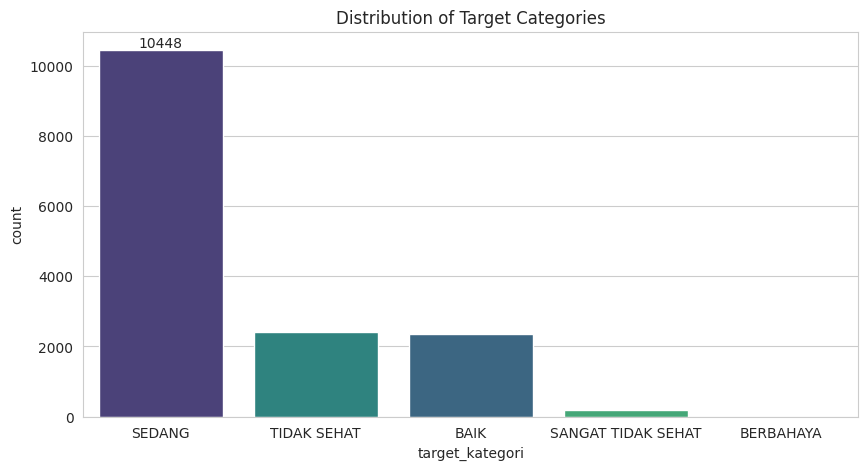

Class Ratios:
target_kategori
SEDANG                0.677913
TIDAK SEHAT           0.157085
BAIK                  0.151960
SANGAT TIDAK SEHAT    0.012977
BERBAHAYA             0.000065
Name: proportion, dtype: float64


In [28]:
plt.figure(figsize=(10, 5))
# Fix: Assign x to hue and set legend=False to avoid FutureWarning
ax = sns.countplot(x='target_kategori', data=df, order=df['target_kategori'].value_counts().index, hue='target_kategori', legend=False, palette='viridis')
plt.title("Distribution of Target Categories")
plt.bar_label(ax.containers[0])
plt.show()

print("Class Ratios:")
print(df['target_kategori'].value_counts(normalize=True))

## 2. Missing Values Analysis
Visualize missing data patterns to ensure imputation strategies worked or identify remaining gaps.

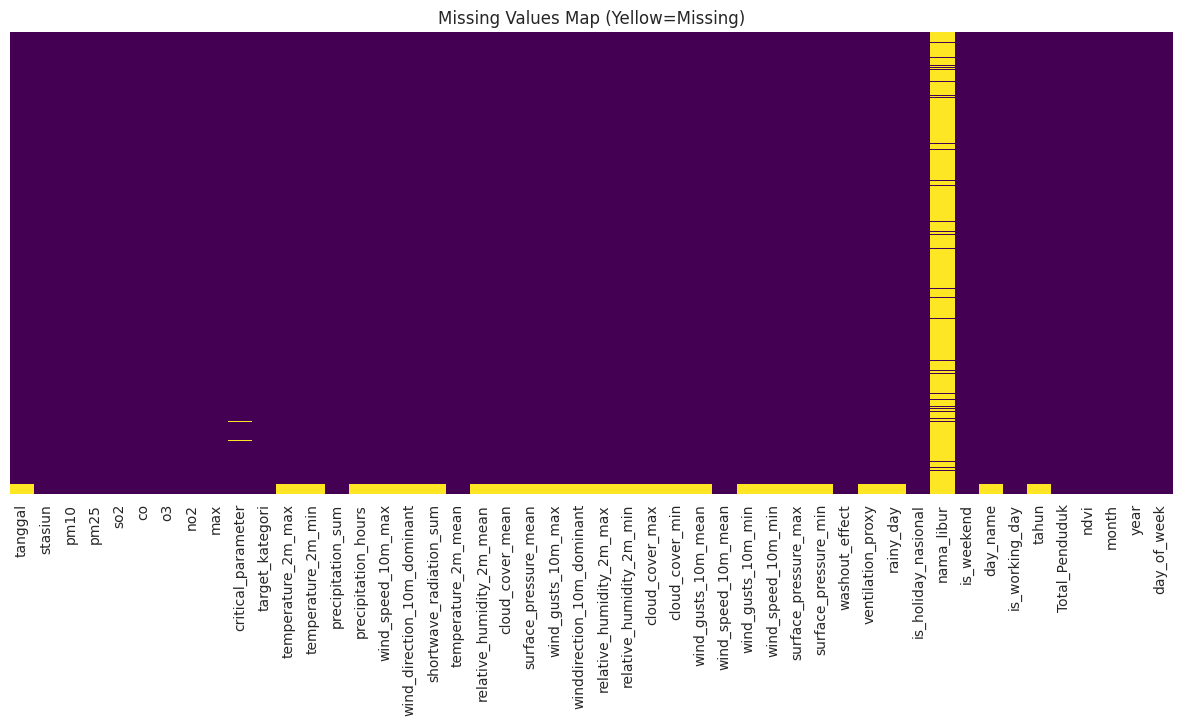

tanggal                          327
stasiun                            2
critical_parameter                46
temperature_2m_max               329
temperature_2m_min               329
precipitation_hours              329
wind_speed_10m_max               329
wind_direction_10m_dominant      329
shortwave_radiation_sum          329
relative_humidity_2m_mean        329
cloud_cover_mean                 329
surface_pressure_mean            329
wind_gusts_10m_max               329
winddirection_10m_dominant       329
relative_humidity_2m_max         329
relative_humidity_2m_min         329
cloud_cover_max                  329
cloud_cover_min                  329
wind_gusts_10m_mean              329
wind_gusts_10m_min               329
wind_speed_10m_min               329
surface_pressure_max             329
surface_pressure_min             329
ventilation_proxy                329
rainy_day                        329
nama_libur                     14706
day_name                         327
t

In [29]:
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Map (Yellow=Missing)")
plt.show()

# List columns with remaining missing values
missing = df.isnull().sum()
print(missing[missing > 0])

## 3. Temporal Trends (Time Series)
Analyze how pollutants change over time (2010-2025).

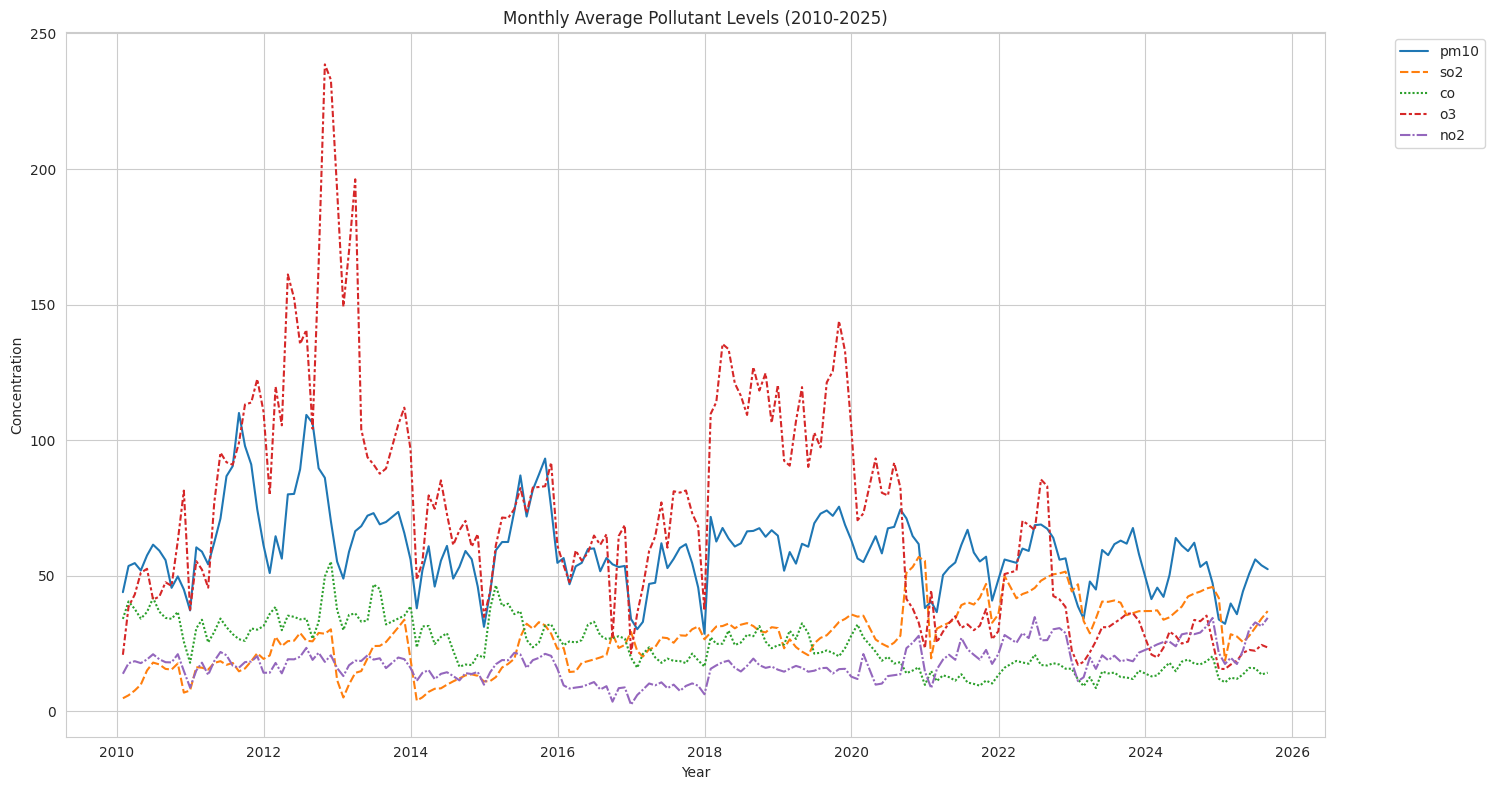

In [30]:
pollutants = ['pm10', 'so2', 'co', 'o3', 'no2']

# Resample to Monthly Average for clearer trends
df_monthly = df.set_index('tanggal')[pollutants].resample('ME').mean()

plt.figure(figsize=(15, 8))
sns.lineplot(data=df_monthly)
plt.title("Monthly Average Pollutant Levels (2010-2025)")
plt.ylabel("Concentration")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Feature Correlations
Relationship between Pollutants, Weather, and NDVI.

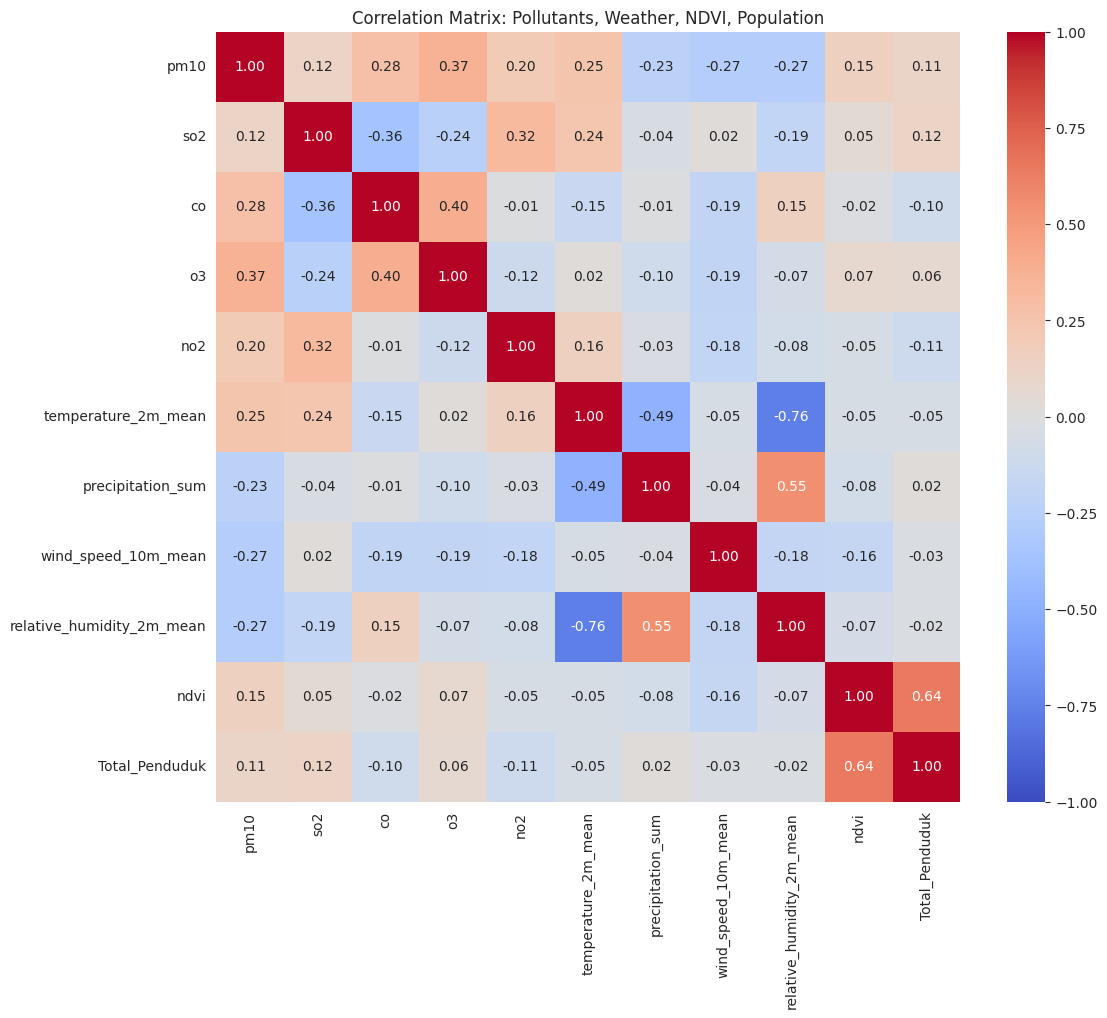

In [31]:
features_corr = pollutants + ['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_mean', 
                            'relative_humidity_2m_mean', 'ndvi', 'Total_Penduduk']
corr_matrix = df[features_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix: Pollutants, Weather, NDVI, Population")
plt.show()

## 5. Station Comparison
Compare pollution levels across different locations (DKI1 - DKI5).

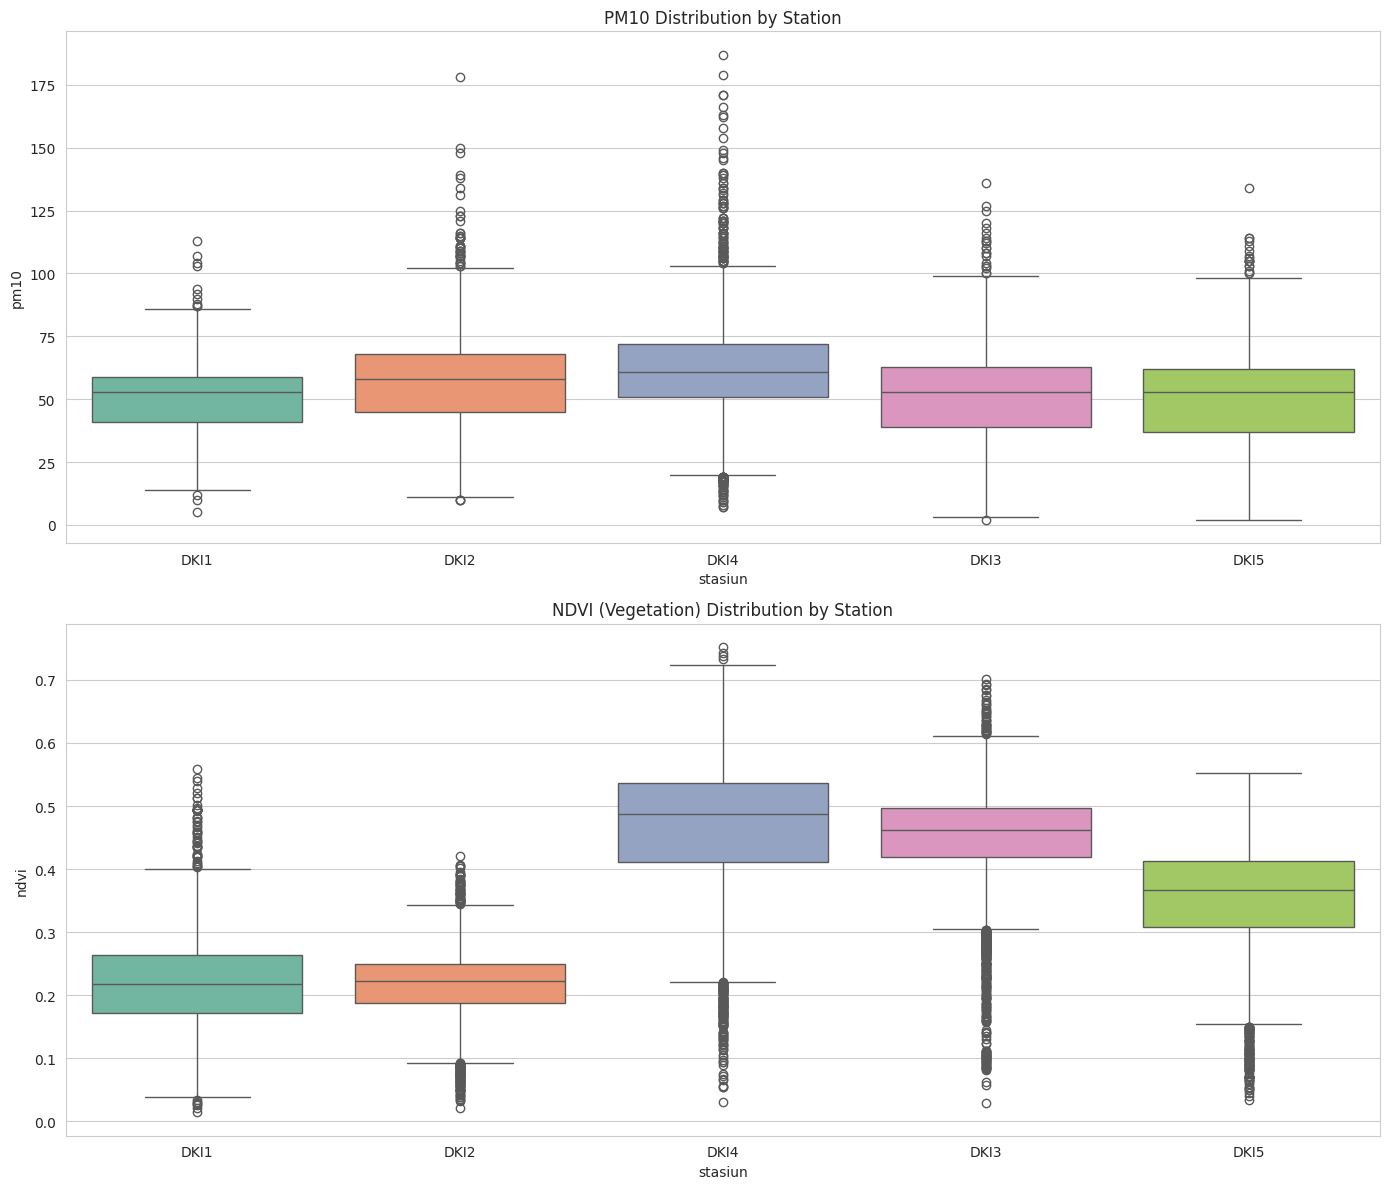

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# PM10 by Station (Fix Future Warning)
sns.boxplot(x='stasiun', y='pm10', data=df, ax=axes[0], hue='stasiun', legend=False, palette='Set2')
axes[0].set_title("PM10 Distribution by Station")

# NDVI by Station (Fix Future Warning)
sns.boxplot(x='stasiun', y='ndvi', data=df, ax=axes[1], hue='stasiun', legend=False, palette='Set2')
axes[1].set_title("NDVI (Vegetation) Distribution by Station")

plt.tight_layout()
plt.show()

## 6. Seasonality (Boxplots)
Analyze Weekly and Monthly patterns.

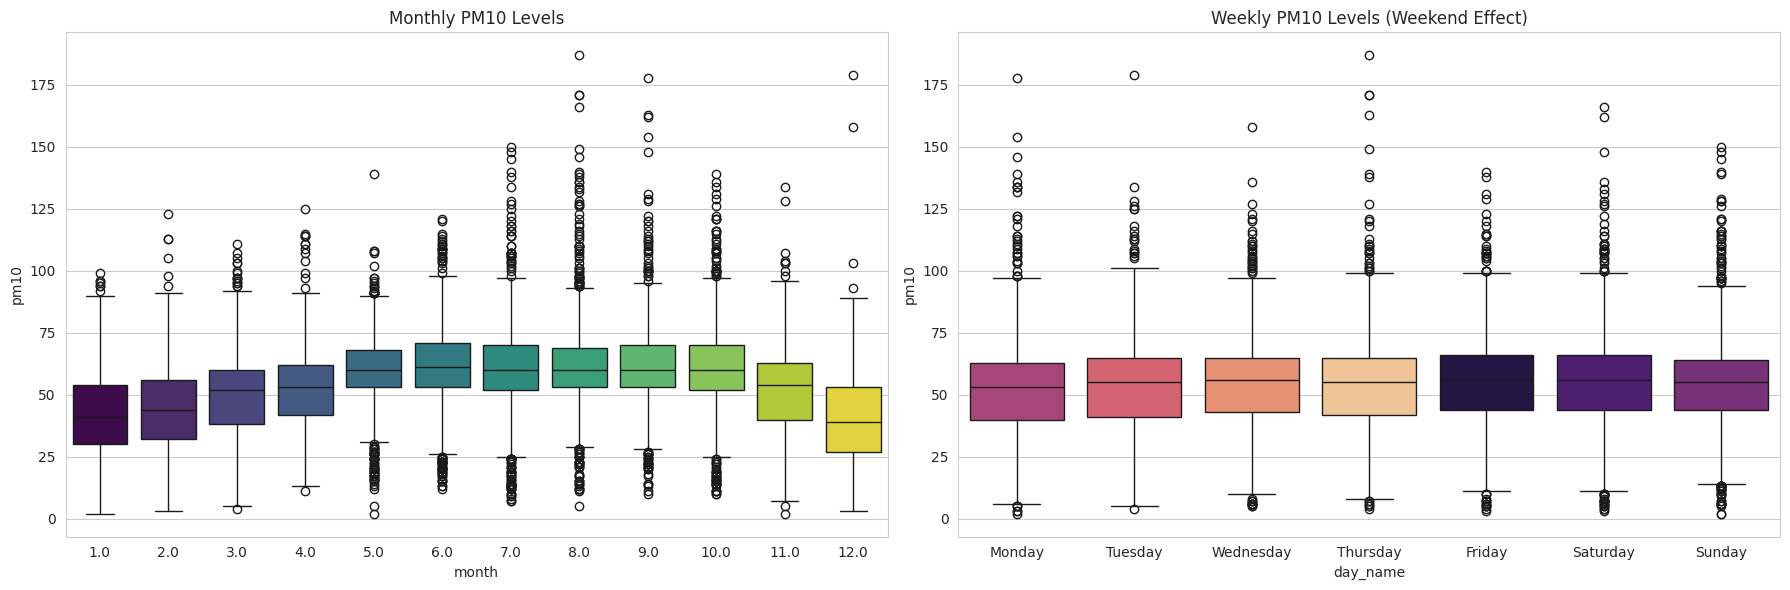

In [33]:
df['month'] = df['tanggal'].dt.month
df['day_name'] = df['tanggal'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Monthly Pattern (Fix Future Warning)
sns.boxplot(x='month', y='pm10', data=df, ax=axes[0], hue='month', legend=False, palette='viridis')
axes[0].set_title("Monthly PM10 Levels")

# Weekly Pattern (Fix Future Warning)
sns.boxplot(x='day_name', y='pm10', order=days_order, data=df, ax=axes[1], hue='day_name', legend=False, palette='magma')
axes[1].set_title("Weekly PM10 Levels (Weekend Effect)")

plt.tight_layout()
plt.show()

## 7. Weather Impact Analysis
Interaction between Rain/Wind and Air Quality.

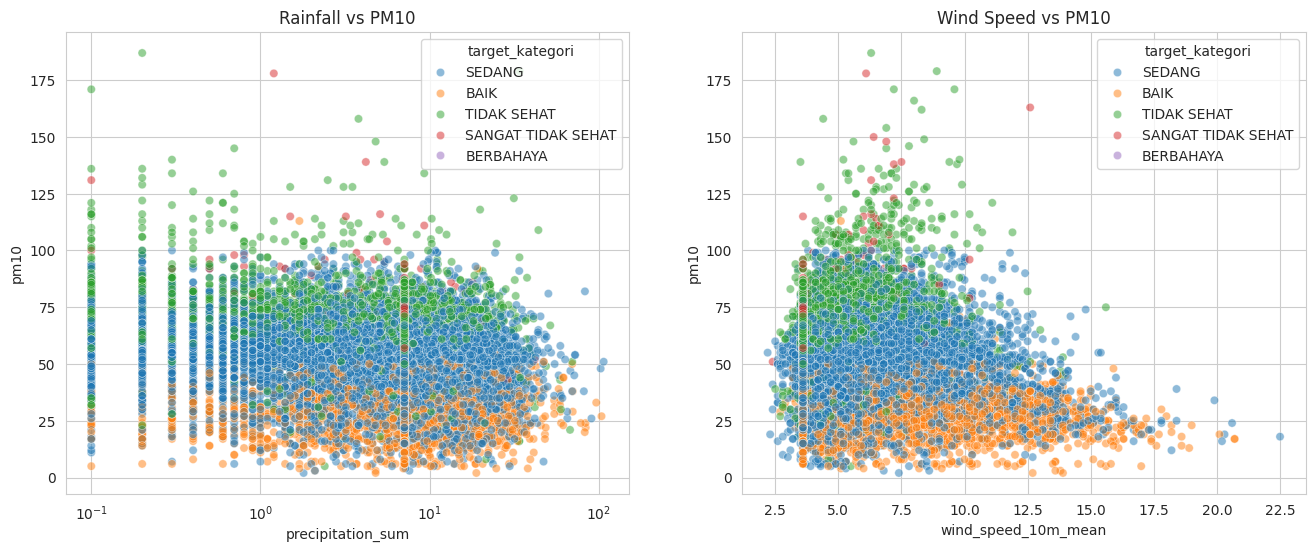

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rain vs PM10
sns.scatterplot(x='precipitation_sum', y='pm10', hue='target_kategori', data=df, alpha=0.5, ax=axes[0])
axes[0].set_title("Rainfall vs PM10")
axes[0].set_xscale('log') # Log scale for rain

# Wind vs PM10
sns.scatterplot(x='wind_speed_10m_mean', y='pm10', hue='target_kategori', data=df, alpha=0.5, ax=axes[1])
axes[1].set_title("Wind Speed vs PM10")

plt.show()

## 8. Deep Dive: Target Category Relationships
Comprehensive analysis of how features vary across `target_kategori`.
**Severity Order:** BAIK -> SEDANG -> TIDAK SEHAT -> SANGAT TIDAK SEHAT -> BERBAHAYA.

In [35]:
# Define Logical Order for Severity
severity_order = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA']
# Filter only categories present in the data
present_categories = [cat for cat in severity_order if cat in df['target_kategori'].unique()]

print(f"Categories present in dataset: {present_categories}")

Categories present in dataset: ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA']


### 8.1 Pollutant Distributions by Category
Visualizing the separation of classes based on pollutant concentrations. Ideally, we should see higher boxplots for worse categories.

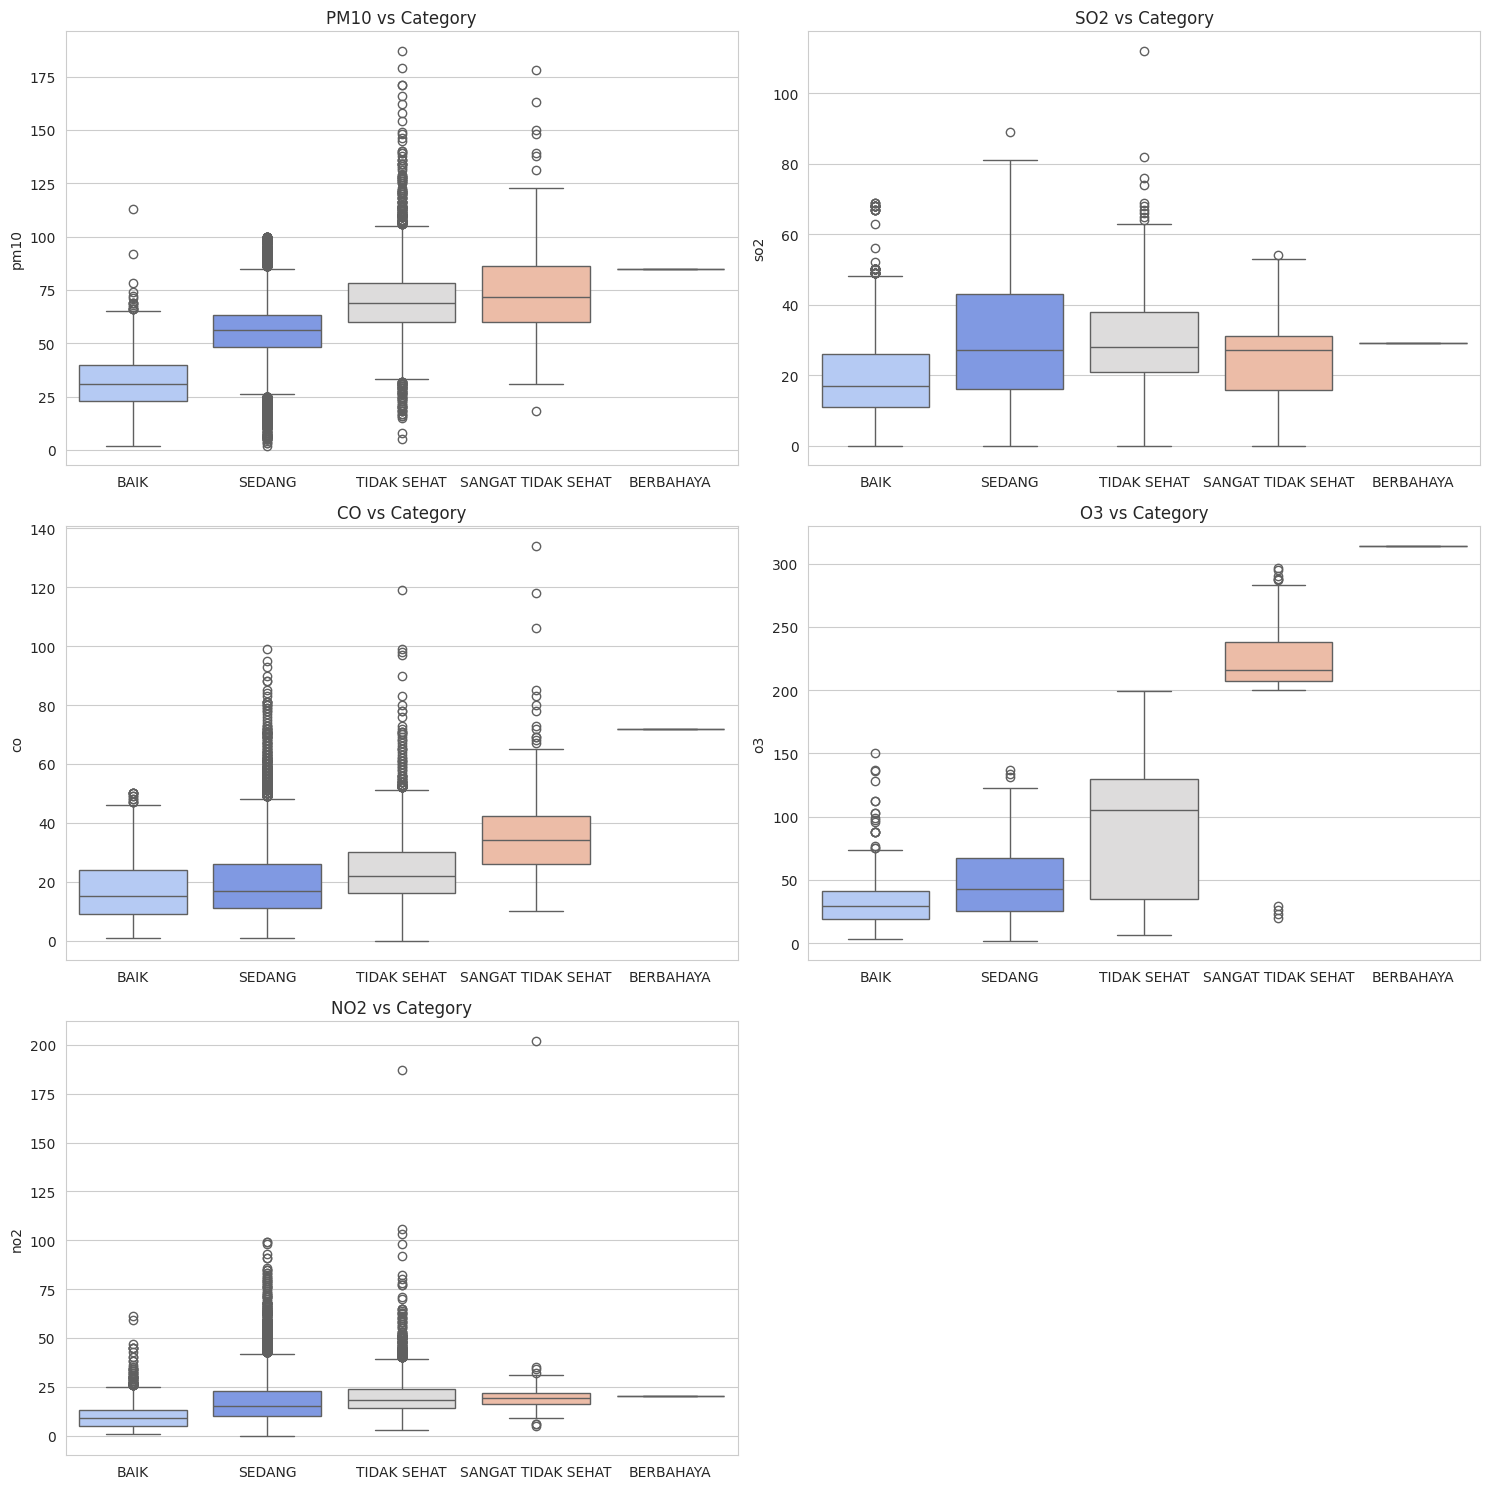

In [36]:
pollutants_diag = ['pm10', 'so2', 'co', 'o3', 'no2']

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(pollutants_diag):
    sns.boxplot(x='target_kategori', y=col, data=df, order=present_categories, 
                hue='target_kategori', legend=False, palette='coolwarm', ax=axes[i])
    axes[i].set_title(f"{col.upper()} vs Category")
    axes[i].set_xlabel('')

# Remove empty subplot if any
if len(pollutants_diag) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### 8.2 External Factors (Weather & NDVI) by Category
Do specific weather conditions or vegetation levels correlate with air quality categories?

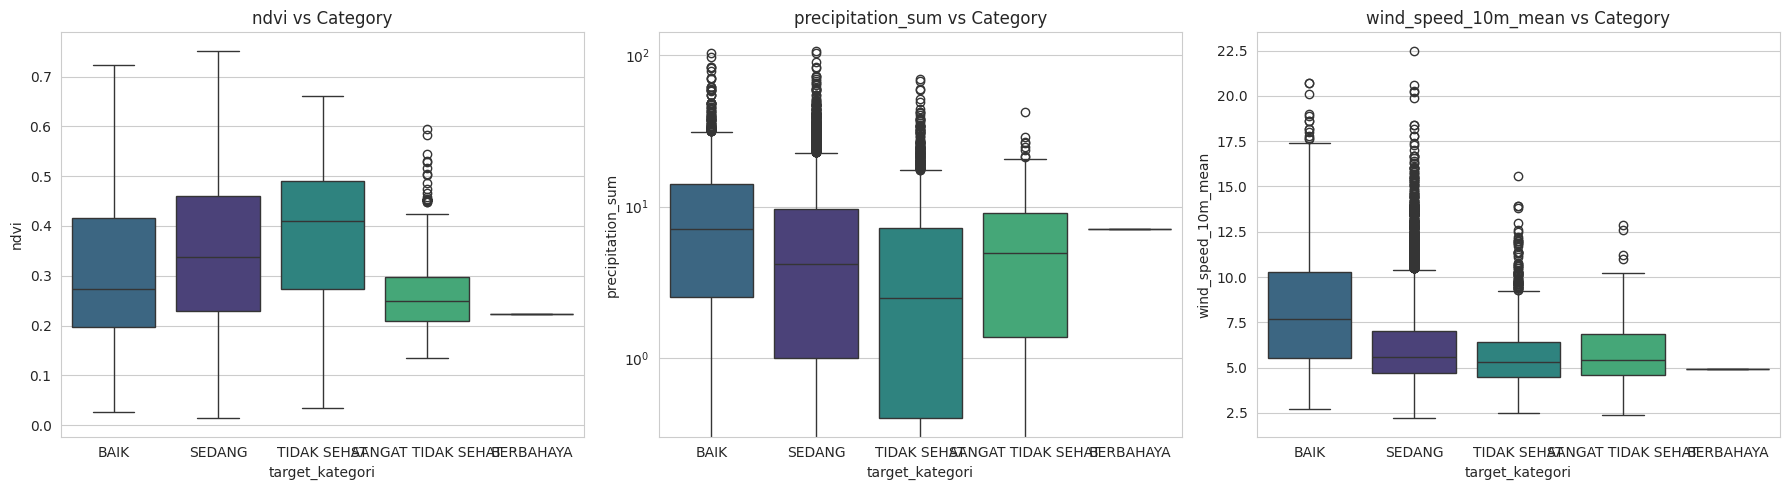

In [37]:
features_ext = ['ndvi', 'precipitation_sum', 'wind_speed_10m_mean']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features_ext):
    sns.boxplot(x='target_kategori', y=col, data=df, order=present_categories, 
                hue='target_kategori', legend=False, palette='viridis', ax=axes[i])
    axes[i].set_title(f"{col} vs Category")
    if col == 'precipitation_sum':
        axes[i].set_yscale('log') # Log scale for rain handling 0s better in visualization visually (optional)

plt.tight_layout()
plt.show()

### 8.3 Composition Analysis (Stacked Bar Charts)
Analyzing the proportion of pollution categories across Stations and Months.
- **Goal:** Identify which station or month is historically the most polluted.

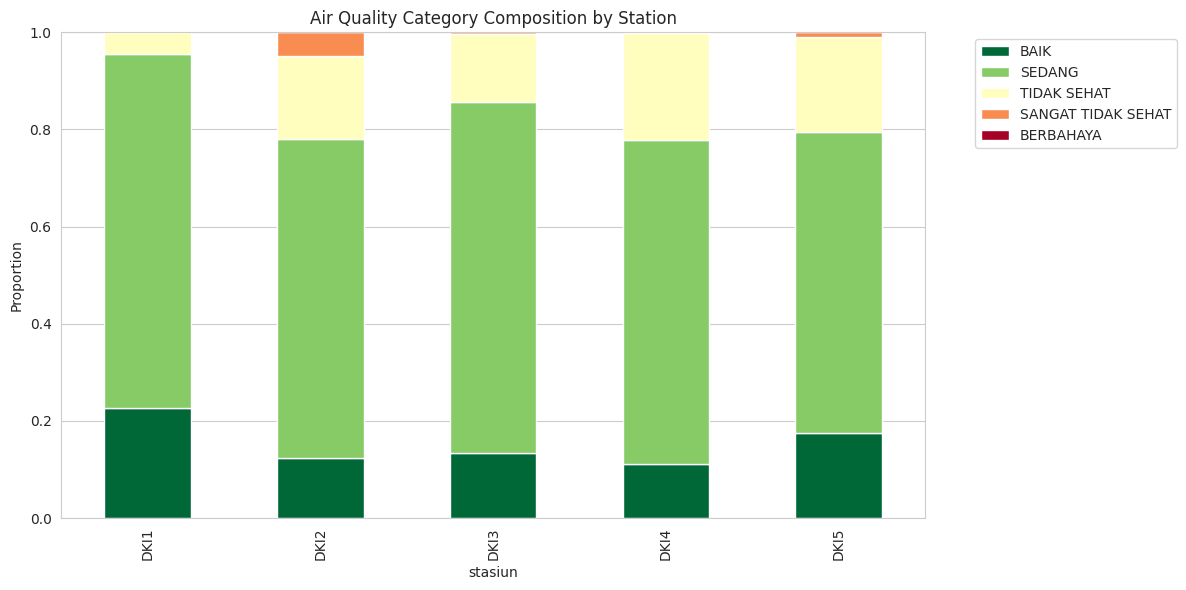

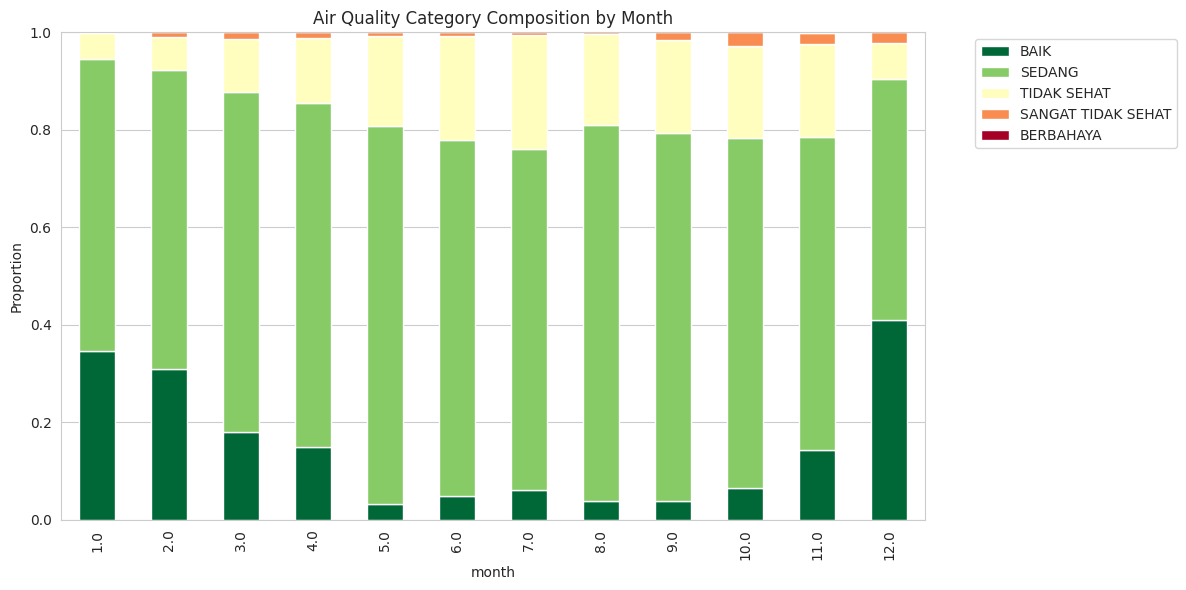

In [38]:
def plot_stacked_composition(col_group, title):
    ct = pd.crosstab(df[col_group], df['target_kategori'], normalize='index')
    # Reorder columns by severity
    ct = ct[present_categories]
    
    ct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='RdYlGn_r')
    plt.title(title)
    plt.ylabel("Proportion")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# 1. Station Composition
plot_stacked_composition('stasiun', "Air Quality Category Composition by Station")

# 2. Monthly Composition
plot_stacked_composition('month', "Air Quality Category Composition by Month")

## 9. Feature Importance Analysis
Ranking features by their predictive power using a Random Forest model.
*Note: `max` and `critical_parameter` are excluded as they are direct derivatives of the target.*

/tmp/ipykernel_59821/3329372911.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_model.select_dtypes(include='object').columns:


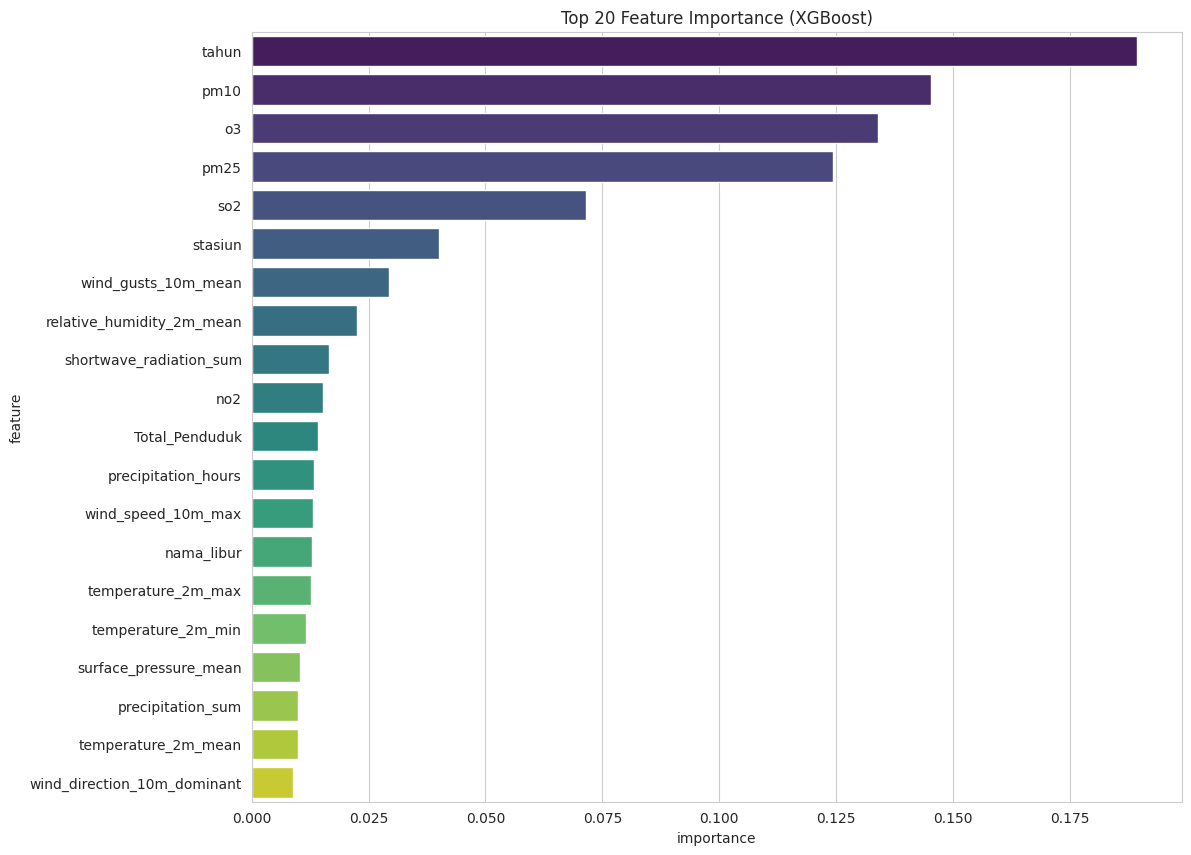

In [39]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Preparation
drop_cols = ['tanggal', 'target_kategori', 'max', 'critical_parameter']
df_model = df.copy().dropna()

# Encode Target
le = LabelEncoder()
y = le.fit_transform(df_model['target_kategori'])

# Encode Categorical Features
for col in df_model.select_dtypes(include='object').columns:
    if col != 'target_kategori':
         df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Define X
X = df_model.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])

# 2. Train Model (XGBoost)
# Use eval_metric to avoid warnings
xgb = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='mlogloss')
xgb.fit(X, y)

# 3. Visualize
importances = pd.DataFrame({'feature': X.columns, 'importance': xgb.feature_importances_})
importances = importances.sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=importances, hue='feature', legend=False, palette='viridis')
plt.title("Top 20 Feature Importance (XGBoost)")
plt.show()

Analyzing 2024 Data per Station...

Total Data Points in 2024: 1824

Station: DKI1 (Year 2024)


/tmp/ipykernel_35067/1632963811.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='target_kategori', data=st_data, order=[x for x in order_list if x in st_data['target_kategori'].unique()], palette='viridis')


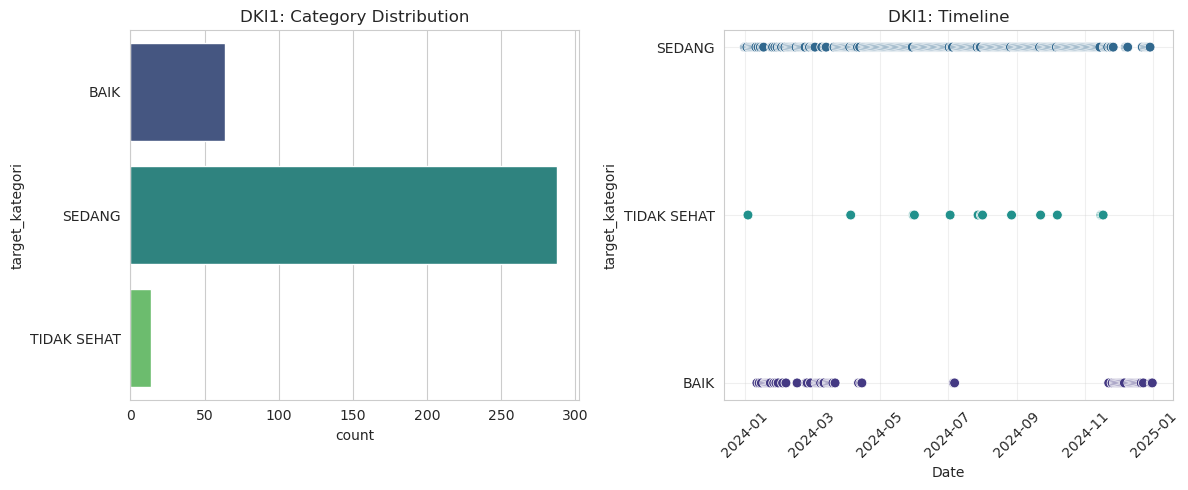


⚠️  Dates with 'TIDAK SEHAT' or worse (14 days):


,tanggal,target_kategori,critical_parameter,max
0,2024-01-04,TIDAK SEHAT,SO2,112.0
1,2024-04-05,TIDAK SEHAT,PM25,102.0
2,2024-05-31,TIDAK SEHAT,PM25,101.0
3,2024-06-01,TIDAK SEHAT,PM25,102.0
4,2024-07-03,TIDAK SEHAT,PM25,103.0
5,2024-07-28,TIDAK SEHAT,PM25,102.0
6,2024-07-31,TIDAK SEHAT,PM25,105.0
7,2024-08-01,TIDAK SEHAT,PM25,103.0
8,2024-08-27,TIDAK SEHAT,PM25,106.0
9,2024-09-22,TIDAK SEHAT,PM25,101.0



Station: DKI2 (Year 2024)


/tmp/ipykernel_35067/1632963811.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='target_kategori', data=st_data, order=[x for x in order_list if x in st_data['target_kategori'].unique()], palette='viridis')


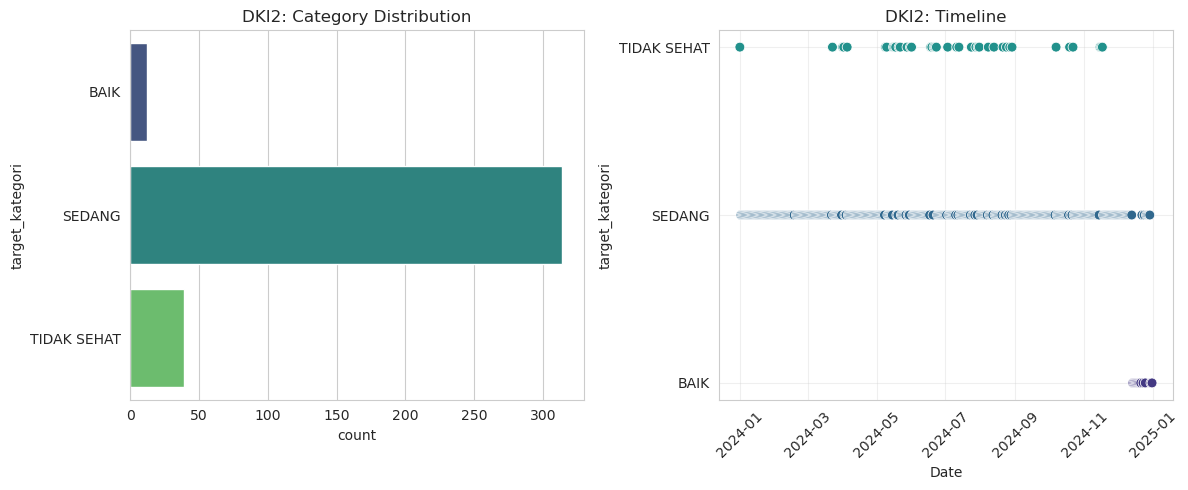


⚠️  Dates with 'TIDAK SEHAT' or worse (39 days):


,tanggal,target_kategori,critical_parameter,max
0,2024-01-01,TIDAK SEHAT,PM25,103.0
1,2024-03-23,TIDAK SEHAT,PM25,111.0
2,2024-04-01,TIDAK SEHAT,PM25,111.0
3,2024-04-02,TIDAK SEHAT,PM25,109.0
4,2024-04-05,TIDAK SEHAT,PM25,112.0
5,2024-05-09,TIDAK SEHAT,PM25,103.0
6,2024-05-10,TIDAK SEHAT,PM25,103.0
7,2024-05-16,TIDAK SEHAT,PM25,115.0
8,2024-05-17,TIDAK SEHAT,PM25,102.0
9,2024-05-18,TIDAK SEHAT,PM25,110.0



Station: DKI3 (Year 2024)


/tmp/ipykernel_35067/1632963811.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='target_kategori', data=st_data, order=[x for x in order_list if x in st_data['target_kategori'].unique()], palette='viridis')


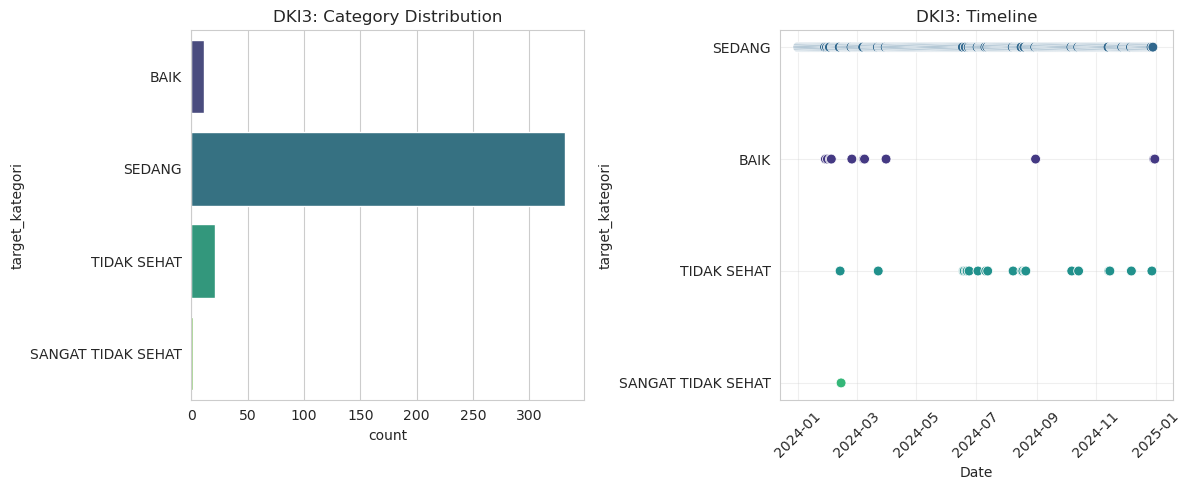


⚠️  Dates with 'TIDAK SEHAT' or worse (22 days):


,tanggal,target_kategori,critical_parameter,max
0,2024-02-13,TIDAK SEHAT,NaN,187.0
1,2024-02-14,SANGAT TIDAK SEHAT,NaN,202.0
2,2024-03-23,TIDAK SEHAT,NaN,106.0
3,2024-06-18,TIDAK SEHAT,PM25,141.0
4,2024-06-19,TIDAK SEHAT,PM25,106.0
5,2024-06-21,TIDAK SEHAT,PM25,105.0
6,2024-06-22,TIDAK SEHAT,PM25,101.0
7,2024-06-24,TIDAK SEHAT,PM25,101.0
8,2024-07-03,TIDAK SEHAT,PM25,106.0
9,2024-07-11,TIDAK SEHAT,PM25,101.0



Station: DKI4 (Year 2024)


/tmp/ipykernel_35067/1632963811.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='target_kategori', data=st_data, order=[x for x in order_list if x in st_data['target_kategori'].unique()], palette='viridis')


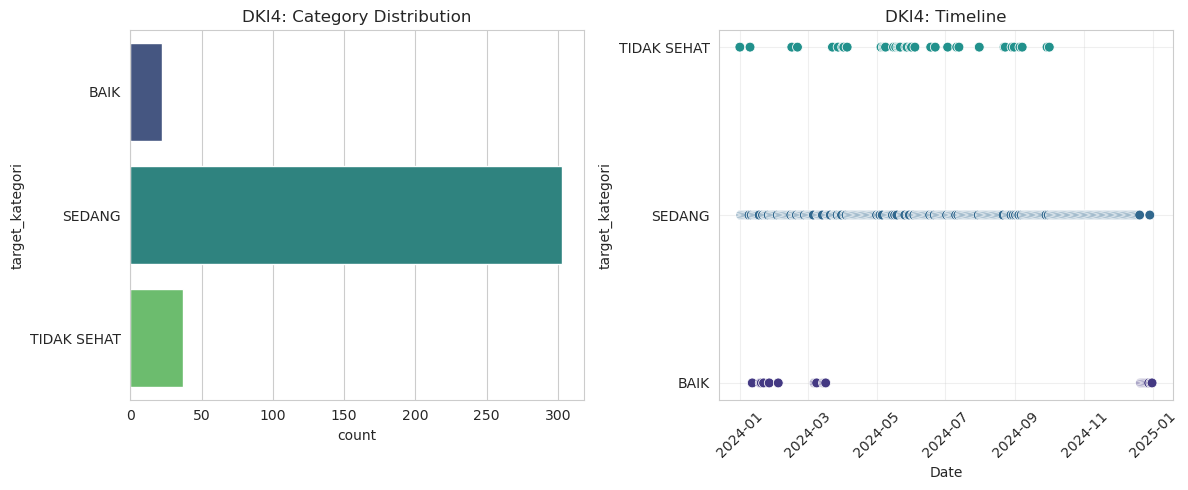


⚠️  Dates with 'TIDAK SEHAT' or worse (37 days):


,tanggal,target_kategori,critical_parameter,max
0,2024-01-01,TIDAK SEHAT,PM25,110.0
1,2024-01-10,TIDAK SEHAT,PM25,102.0
2,2024-02-16,TIDAK SEHAT,PM25,103.0
3,2024-02-21,TIDAK SEHAT,PM25,102.0
4,2024-03-23,TIDAK SEHAT,PM25,122.0
5,2024-03-28,TIDAK SEHAT,PM25,128.0
6,2024-04-01,TIDAK SEHAT,PM25,113.0
7,2024-04-02,TIDAK SEHAT,PM25,112.0
8,2024-04-05,TIDAK SEHAT,PM25,116.0
9,2024-05-05,TIDAK SEHAT,PM25,107.0



Station: DKI5 (Year 2024)


/tmp/ipykernel_35067/1632963811.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='target_kategori', data=st_data, order=[x for x in order_list if x in st_data['target_kategori'].unique()], palette='viridis')


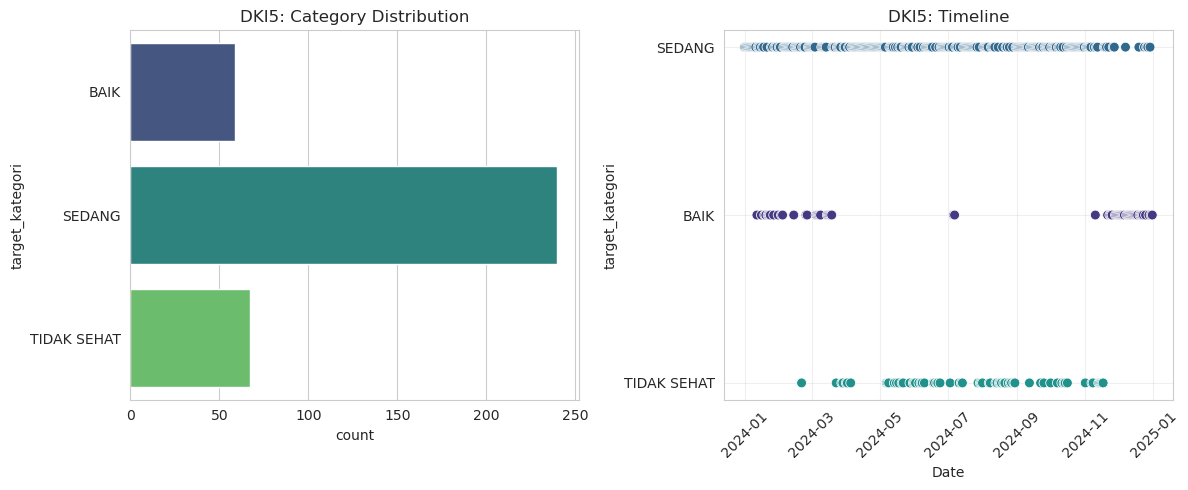


⚠️  Dates with 'TIDAK SEHAT' or worse (67 days):


,tanggal,target_kategori,critical_parameter,max
0,2024-02-21,TIDAK SEHAT,O3,115.0
1,2024-03-23,TIDAK SEHAT,PM25,108.0
2,2024-03-28,TIDAK SEHAT,PM25,109.0
3,2024-03-29,TIDAK SEHAT,PM25,104.0
4,2024-04-01,TIDAK SEHAT,PM25,104.0
...,...,...,...,...
62,2024-11-13,TIDAK SEHAT,PM25,113.0
63,2024-11-14,TIDAK SEHAT,PM25,124.0
64,2024-11-15,TIDAK SEHAT,PM25,133.0
65,2024-11-16,TIDAK SEHAT,PM25,141.0


In [3]:
# 3. Target Variable Analysis by Station (2024)
print("Analyzing 2024 Data per Station...\n")

df_2024 = df[df['year'] == 2024].copy()
stations = sorted(df_2024['stasiun'].unique())

print(f"Total Data Points in 2024: {len(df_2024)}")

for station in stations:
    st_data = df_2024[df_2024['stasiun'] == station].sort_values('tanggal')
    
    print(f"\n{'='*60}\nStation: {station} (Year 2024)\n{'='*60}")
    
    # 1. Distribution Plot
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    order_list = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA']
    sns.countplot(y='target_kategori', data=st_data, order=[x for x in order_list if x in st_data['target_kategori'].unique()], palette='viridis')
    plt.title(f"{station}: Category Distribution")
    
    # 2. Timeline Scatter Plot
    plt.subplot(1, 2, 2)
    sns.scatterplot(x='tanggal', y='target_kategori', data=st_data, hue='target_kategori', 
                    hue_order=order_list,
                    palette='viridis', s=50, legend=False)
    plt.title(f"{station}: Timeline")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 3. List Dates for 'TIDAK SEHAT' or worse
    bad_days = st_data[st_data['target_kategori'].isin(['TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA'])]
    if not bad_days.empty:
        print(f"\n⚠️  Dates with 'TIDAK SEHAT' or worse ({len(bad_days)} days):")
        display(bad_days[['tanggal', 'target_kategori', 'critical_parameter', 'max']].reset_index(drop=True))
    else:
        print("\n✅ No 'TIDAK SEHAT' days recorded in 2024.")


Loading data from: dataset/data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data.csv

Found 87 valid records matching criteria.

--- Detailed Records by Station ---


,stasiun,full_date,day_name,kategori,pm_sepuluh,pm_duakomalima
2917,DKI1 Bundaran Hotel Indonesia (HI),2025-09-17,Wednesday,TIDAK SEHAT,66.0,109.0
2924,DKI1 Bundaran Hotel Indonesia (HI),2025-09-24,Wednesday,TIDAK SEHAT,62.0,103.0
2925,DKI1 Bundaran Hotel Indonesia (HI),2025-09-25,Thursday,TIDAK SEHAT,66.0,115.0
3200,DKI1 Bundaran Hotel Indonesia (HI),2025-10-05,Sunday,TIDAK SEHAT,66.0,103.0
3201,DKI1 Bundaran Hotel Indonesia (HI),2025-10-06,Monday,TIDAK SEHAT,58.0,101.0
3215,DKI1 Bundaran Hotel Indonesia (HI),2025-10-20,Monday,TIDAK SEHAT,62.0,102.0
3356,DKI1 Bundaran Hotel Indonesia (HI),2025-11-06,Thursday,BAIK,22.0,45.0
3357,DKI1 Bundaran Hotel Indonesia (HI),2025-11-07,Friday,BAIK,21.0,48.0
3360,DKI1 Bundaran Hotel Indonesia (HI),2025-11-10,Monday,BAIK,21.0,50.0
3361,DKI1 Bundaran Hotel Indonesia (HI),2025-11-11,Tuesday,BAIK,23.0,47.0



--- Date List by Station ---

Station: DKI1 Bundaran Hotel Indonesia (HI)
1. 2025-09-17 (Wednesday) - TIDAK SEHAT
2. 2025-09-24 (Wednesday) - TIDAK SEHAT
3. 2025-09-25 (Thursday) - TIDAK SEHAT
4. 2025-10-05 (Sunday) - TIDAK SEHAT
5. 2025-10-06 (Monday) - TIDAK SEHAT
6. 2025-10-20 (Monday) - TIDAK SEHAT
7. 2025-11-06 (Thursday) - BAIK
8. 2025-11-07 (Friday) - BAIK
9. 2025-11-10 (Monday) - BAIK
10. 2025-11-11 (Tuesday) - BAIK
11. 2025-11-12 (Wednesday) - BAIK
12. 2025-11-13 (Thursday) - BAIK
13. 2025-11-14 (Friday) - BAIK
14. 2025-11-21 (Friday) - BAIK
15. 2025-11-28 (Friday) - TIDAK SEHAT

Station: DKI2 Kelapa Gading
1. 2025-09-17 (Wednesday) - TIDAK SEHAT
2. 2025-09-19 (Friday) - TIDAK SEHAT
3. 2025-09-22 (Monday) - BAIK
4. 2025-09-25 (Thursday) - TIDAK SEHAT
5. 2025-10-05 (Sunday) - TIDAK SEHAT
6. 2025-10-25 (Saturday) - BAIK
7. 2025-11-06 (Thursday) - BAIK
8. 2025-11-07 (Friday) - BAIK
9. 2025-11-08 (Saturday) - BAIK
10. 2025-11-09 (Sunday) - BAIK
11. 2025-11-10 (Monday) - BAIK
12. 

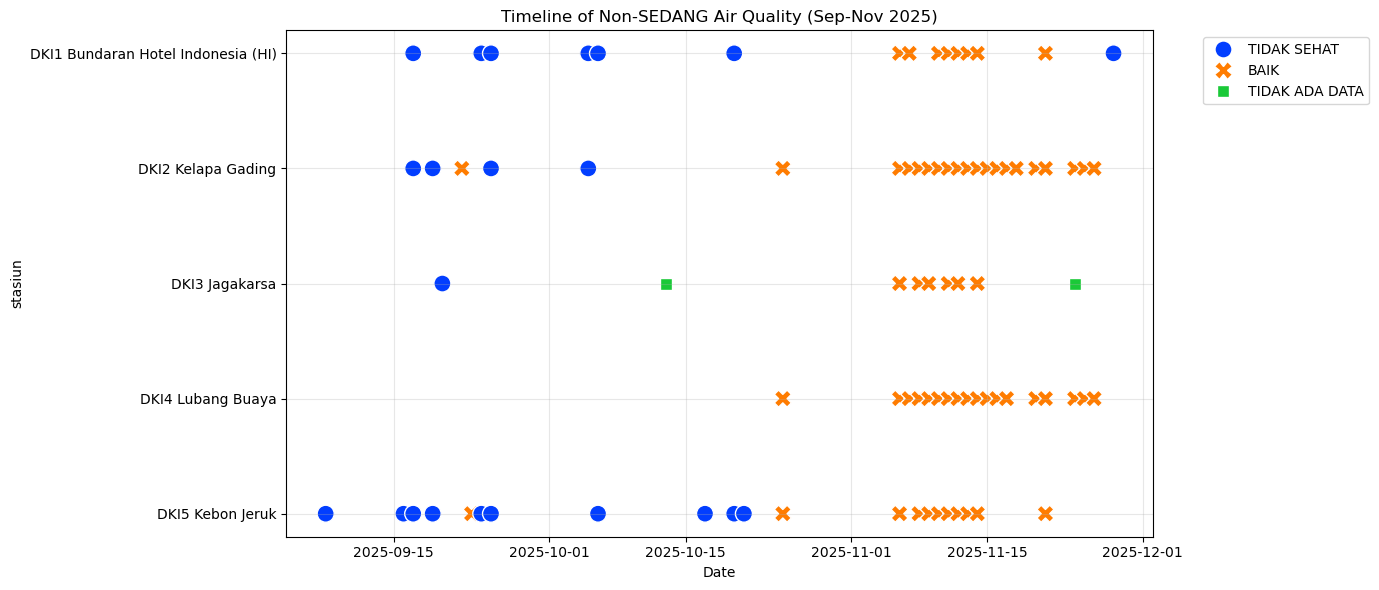

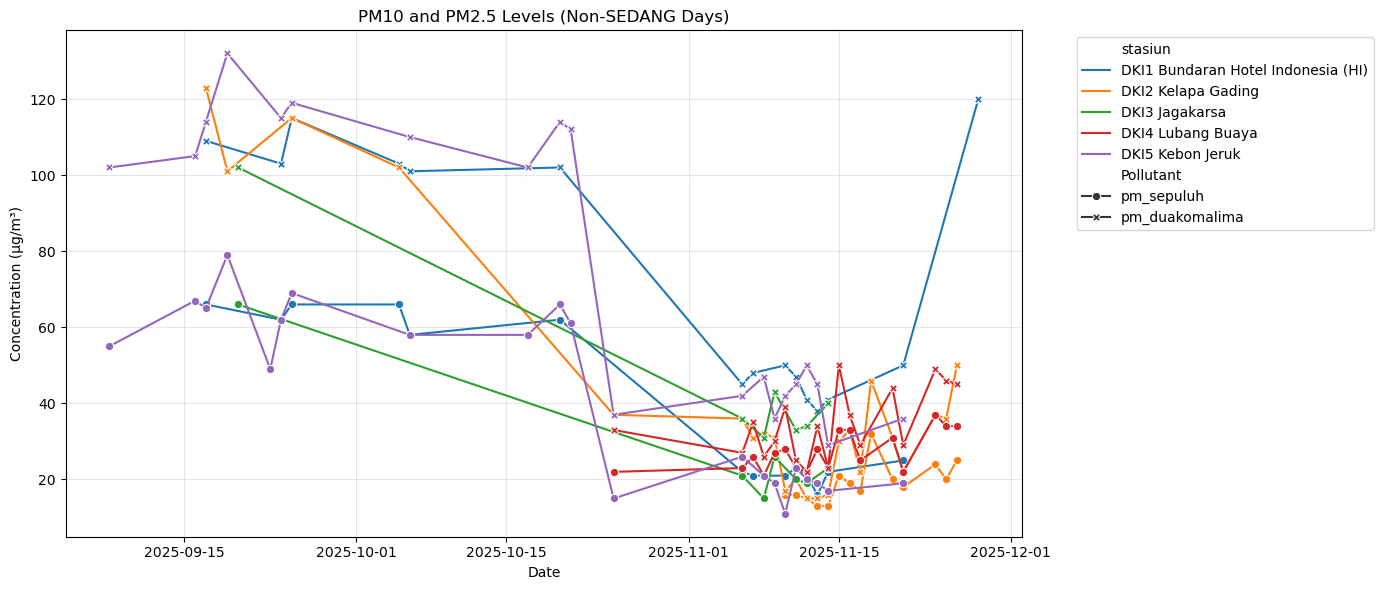

In [12]:
# 4. Targeted Visualization for 2025 (Sep-Nov) - Non-SEDANG Category (Detailed Dates)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load specific dataset as requested
file_path_ispu = 'dataset/data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data.csv'
print(f"Loading data from: {file_path_ispu}")
try:
    df_ispu = pd.read_csv(file_path_ispu)
    
    # 1. Preprocessing
    # Ensure year is extracted correctly
    df_ispu['year'] = df_ispu['periode_data'].astype(str).str[:4].astype(int)
    
    # Convert Pollutant columns to numeric, handling N/A
    numeric_cols = ['pm_sepuluh', 'pm_duakomalima']
    for col in numeric_cols:
        df_ispu[col] = pd.to_numeric(df_ispu[col], errors='coerce')
    
    # 2. Filter Data
    # Filter 1: Year 2025, Months 9, 10, 11
    mask_time = (df_ispu['year'] == 2025) & (df_ispu['bulan'].isin([9, 10, 11]))
    # Filter 2: Category is NOT 'SEDANG'
    mask_cat = df_ispu['kategori'] != 'SEDANG'
    
    df_target = df_ispu[mask_time & mask_cat].copy()
    
    if not df_target.empty:
        # Create a full date for plotting, handling invalid dates
        df_target['full_date'] = pd.to_datetime(
            df_target[['year', 'bulan', 'tanggal']].rename(columns={'bulan': 'month', 'tanggal': 'day'}),
            errors='coerce'
        )
        
        # Drop invalid dates
        df_target = df_target.dropna(subset=['full_date'])
        df_target = df_target.sort_values(['stasiun', 'full_date'])
        df_target['day_name'] = df_target['full_date'].dt.day_name()
        
        print(f"\nFound {len(df_target)} valid records matching criteria.")
        
        # 3. Detailed Data Table (Force showing all rows)
        print("\n--- Detailed Records by Station ---")
        with pd.option_context('display.max_rows', None):
            display_cols = ['stasiun', 'full_date', 'day_name', 'kategori', 'pm_sepuluh', 'pm_duakomalima']
            display(df_target[display_cols])
            
        # 4. List Dates specifically per station for clarity
        print("\n--- Date List by Station ---")
        for station, group in df_target.groupby('stasiun'):
            print(f"\nStation: {station}")
            # Zip dates, categories, and day names for printing
            dates = group['full_date'].dt.strftime('%Y-%m-%d').tolist()
            days = group['day_name'].tolist()
            cats = group['kategori'].tolist()
            
            for i, (d, day, cat) in enumerate(zip(dates, days, cats), 1):
                 print(f"{i}. {d} ({day}) - {cat}")
        
        # 5. Visualizations
        # Plot 1: Timeline Scatter
        plt.figure(figsize=(14, 6))
        sns.scatterplot(data=df_target, x='full_date', y='stasiun', 
                        hue='kategori', style='kategori', 
                        palette='bright', s=150)
        plt.title("Timeline of Non-SEDANG Air Quality (Sep-Nov 2025)")
        plt.xlabel("Date")
        plt.grid(True, alpha=0.3)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        
        # Plot 2: PM10 and PM2.5 Trends
        df_long = df_target.melt(id_vars=['stasiun', 'full_date', 'kategori'], 
                                 value_vars=['pm_sepuluh', 'pm_duakomalima'], 
                                 var_name='Pollutant', value_name='Level')
        
        plt.figure(figsize=(14, 6))
        sns.lineplot(data=df_long, x='full_date', y='Level', hue='stasiun', style='Pollutant', markers=True, dashes=False)
        plt.title("PM10 and PM2.5 Levels (Non-SEDANG Days)")
        plt.xlabel("Date")
        plt.ylabel("Concentration (µg/m³)")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    else:
        print("\nNo data found for Year 2025, Months 9-11 with Category != 'SEDANG'.")
        
except Exception as e:
    print(f"Error: {e}")